In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kan vi importere tidymodels data som R fil, ikke CSV?

# !pip install pyreadr

import pyreadr

model_data = pyreadr.read_r("model_data_clean.rds")[None]

print(model_data.info())

# ── FEATURES ────────────────────────────────────────────────────────────────

target_col = "churn"

quant_cols = [
    "account_active_days",
    "previous_subscriptions",
    "previous_campaigns",
    "previous_trials",
    "newsletters_before_order",
    "newsletters_after_order",
    "age"
]

cat_cols = [
    "koen",
    "permission_given_order",
    "permission_given_today",
    "kundetid_gruppe",
    "cluster_label"
]

# ── TARGET ──────────────────────────────────────────────────────────────────
y = model_data[target_col].astype(int).values

# ── FEATURES ────────────────────────────────────────────────────────────────
X_cat_dummies = pd.get_dummies(model_data[cat_cols], drop_first=False)

X_df = pd.concat(
    [model_data[quant_cols].reset_index(drop=True),
     X_cat_dummies.reset_index(drop=True)],
    axis=1
)

# ── TRAIN/TEST SPLIT ────────────────────────────────────────────────────────
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=8, stratify=y
)

# ── SCALING ─────────────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_arr = X_train_df.copy()
X_test_arr = X_test_df.copy()

X_train_arr[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_arr[quant_cols] = scaler.transform(X_test_df[quant_cols])

# ── FINAL ARRAYS ────────────────────────────────────────────────────────────
X_train = X_train_arr.values.astype(np.float32)
X_test = X_test_arr.values.astype(np.float32)

# ── CHECK ───────────────────────────────────────────────────────────────────
print(X_train.shape)
print("Churn rate:", y_train.mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   account_active_days       1260 non-null   int32   
 1   koen                      1260 non-null   category
 2   permission_given_order    1260 non-null   category
 3   permission_given_today    1260 non-null   category
 4   previous_subscriptions    1260 non-null   int32   
 5   previous_campaigns        1260 non-null   int32   
 6   previous_trials           1260 non-null   int32   
 7   newsletters_before_order  1260 non-null   int32   
 8   newsletters_after_order   1260 non-null   int32   
 9   churn                     1260 non-null   category
 10  early_churn               1260 non-null   float64 
 11  age                       1260 non-null   float64 
 12  kundetid_gruppe           1260 non-null   category
 13  cluster_label             1260 non-null   catego

In [ ]:
# model_01
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD MODEL 01 ────────────────────────────────────────────────────────
# X_train.shape[1] automatically knows how many features you have from before
model_01 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
], name="baseline_nn")

model_01.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 3. TRAINING ──────────────────────────────────────────────────────────────
# Using y_train and X_train directly from your previous script execution
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Model 01 (Baseline)...")
history_01 = model_01.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# ── 4. EVALUATE ──────────────────────────────────────────────────────────────
# Using X_test and y_test from your previous script execution
metrics_01 = model_01.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*30)
print(f"Model 01 TEST AUC: {metrics_01[2]:.4f}")
print(f"Model 01 TEST ACC: {metrics_01[1]:.4f}")
print("="*30)

Training Model 01 (Baseline)...
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5558 - auc: 0.5224 - loss: 0.7641 - val_accuracy: 0.5990 - val_auc: 0.5860 - val_loss: 0.7413
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5906 - auc: 0.5666 - loss: 0.7440 - val_accuracy: 0.5743 - val_auc: 0.6385 - val_loss: 0.7351
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6017 - auc: 0.6201 - loss: 0.7299 - val_accuracy: 0.5693 - val_auc: 0.6633 - val_loss: 0.7263
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6055 - auc: 0.6401 - loss: 0.7221 - val_accuracy: 0.5891 - val_auc: 0.6665 - val_loss: 0.7202
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6166 - auc: 0.6573 - loss: 0.7112 - val_accuracy: 0.5941 - val_auc: 0.6785 - val_loss: 0.7120
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6216 - auc: 0.6476 - loss: 0.7073 - val_accuracy: 0.6139 - val_auc: 0.6845 - val_loss: 0.7077
Epoch 7/150
2

In [ ]:
# model_02
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD THE DEEP MODEL (Complex Architecture) ───────────────────────────
model_02 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    # Layer 1: Wide initial layer + BatchNormalization
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Layer 2: Medium layer
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.Dropout(0.3),

    # Layer 3: Final refinement
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation="sigmoid")
], name="complex_nn_model")

# Using a custom learning rate as per your Model 02 setup
model_02.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")]
)

# ── 3. ADVANCED CALLBACKS ────────────────────────────────────────────────────
# These help the model navigate complex loss landscapes
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# ── 4. TRAIN ─────────────────────────────────────────────────────────────────
print("Training Model 02 (Complex NN)...")
history_02 = model_02.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── 5. EVALUATE ──────────────────────────────────────────────────────────────
metrics_02 = model_02.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*40)
print(f"Model 02 TEST AUC:      {metrics_02[2]:.4f}")
print(f"Model 02 TEST RECALL:   {metrics_02[3]:.4f}")
print(f"Model 02 TEST ACC:      {metrics_02[1]:.4f}")
print("="*40)

Training Model 02 (Complex NN)...
Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5124 - auc: 0.4982 - loss: 1.0713 - recall: 0.3246 - val_accuracy: 0.5495 - val_auc: 0.5980 - val_loss: 0.9313 - val_recall: 0.7407 - learning_rate: 0.0010
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5918 - auc: 0.6253 - loss: 0.9250 - recall: 0.4737 - val_accuracy: 0.5990 - val_auc: 0.6380 - val_loss: 0.9211 - val_recall: 0.6667 - learning_rate: 0.0010
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6526 - auc: 0.6926 - loss: 0.8722 - recall: 0.5058 - val_accuracy: 0.6337 - val_auc: 0.6688 - val_loss: 0.9087 - val_recall: 0.6173 - learning_rate: 0.0010
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6216 - auc: 0.6577 - loss: 0.8907 - recall: 0.4825 - val_accuracy: 0.6337 - val_auc: 0.6961 - val_loss: 0.8977 - val_recall: 0.6173 - learning_rate: 0.0010
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6104 - auc: 0.64

In [ ]:
# model_03
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, backend as K

K.clear_session()
tf.random.set_seed(8)

# ── 2. APPLY SMOTE (Balancing the Training Set) ──────────────────────────────
# We use X_train and y_train that were already prepped and scaled
# in your cleaning script.
sm = SMOTE(random_state=8)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape (SMOTE): {X_train_res.shape}")

# ── 3. BUILD MODEL 03 (Architecture matching your R-style setup) ──────────────
model_03 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_smote_balanced")

model_03.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 4. TRAINING ──────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("Training Model 03 (SMOTE Balanced)...")
history_03 = model_03.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test), # Validate on the original, un-SMOTEd test data
    callbacks=[early_stop],
    verbose=1
)

# ── 5. EVALUATION ────────────────────────────────────────────────────────────
results_03 = model_03.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*35)
print(f"MODEL 03 TEST AUC:      {results_03[2]:.4f}")
print(f"MODEL 03 TEST ACCURACY: {results_03[1]:.4f}")
print("="*35)

Original shape: (1008, 23)
Resampled shape (SMOTE): (1170, 23)
Training Model 03 (SMOTE Balanced)...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5179 - auc: 0.5237 - loss: 0.7254 - val_accuracy: 0.5833 - val_auc: 0.5633 - val_loss: 0.7155
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5795 - auc: 0.6028 - loss: 0.7004 - val_accuracy: 0.5952 - val_auc: 0.6261 - val_loss: 0.7039
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5650 - auc: 0.6014 - loss: 0.6985 - val_accuracy: 0.6151 - val_auc: 0.6654 - val_loss: 0.6928
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6325 - auc: 0.6773 - loss: 0.6762 - val_accuracy: 0.6270 - val_auc: 0.6843 - val_loss: 0.6833
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6419 - auc: 0.6926 - loss: 0.6643 - val_accuracy: 0.6548 - val_auc: 0.6902 - val_loss: 0.6701
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6419 - auc: 0.7080 - loss: 0.6522 - va

In [ ]:
# model_04
from imblearn.over_sampling import SMOTENC
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, backend as K

K.clear_session()
tf.random.set_seed(8)

# ── 1. IDENTIFY CATEGORICAL FEATURE INDICES ────────────────────────────────
# These are the one-hot encoded columns
categorical_cols = X_cat_dummies.columns.tolist()
cat_idx = [X_train_df.columns.get_loc(col) for col in categorical_cols]

# ── 2. APPLY SMOTENC (Correct handling of mixed data) ───────────────────────
sm = SMOTENC(
    categorical_features=cat_idx,
    random_state=8,
    k_neighbors=5
)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape (SMOTENC): {X_train_res.shape}")

# ── 3. MODEL ARCHITECTURE ───────────────────────────────────────────────────
model_04 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_smotenc_balanced")

model_04.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 4. TRAINING ─────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

print("Training Model 04 (SMOTENC Balanced)...")
history_04 = model_04.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),  # untouched test set
    callbacks=[early_stop],
    verbose=1
)

# ── 5. EVALUATION ───────────────────────────────────────────────────────────
results_04 = model_04.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*35)
print(f"MODEL 04 TEST AUC:      {results_04[2]:.4f}")
print(f"MODEL 04 TEST ACCURACY: {results_04[1]:.4f}")
print("="*35)

Original shape: (1008, 23)
Resampled shape (SMOTENC): (1170, 23)
Training Model 04 (SMOTENC Balanced)...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5034 - auc: 0.4919 - loss: 0.7487 - val_accuracy: 0.5595 - val_auc: 0.6448 - val_loss: 0.7098
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5658 - auc: 0.5844 - loss: 0.7140 - val_accuracy: 0.5794 - val_auc: 0.7000 - val_loss: 0.6979
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6179 - auc: 0.6417 - loss: 0.6905 - val_accuracy: 0.6349 - val_auc: 0.7074 - val_loss: 0.6866
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6222 - auc: 0.6671 - loss: 0.6777 - val_accuracy: 0.6429 - val_auc: 0.7163 - val_loss: 0.6809
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6530 - auc: 0.6987 - loss: 0.6639 - val_accuracy: 0.6310 - val_auc: 0.7189 - val_loss: 0.6746
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6513 - auc: 0.7018 - loss: 0.6578 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


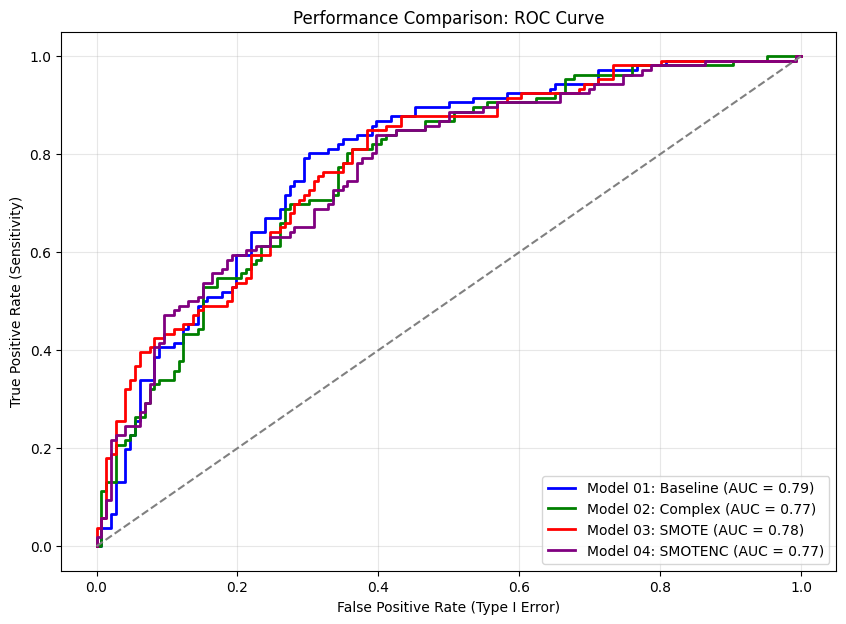

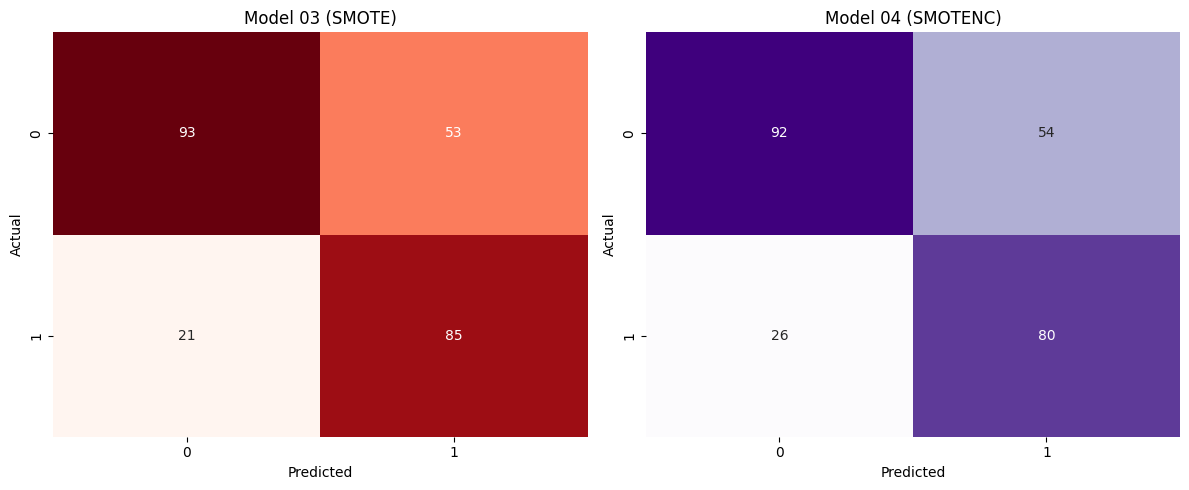


--- Model Performance Leaderboard ---
              Model   AUC  Recall (Churn Caught)  Accuracy
Model 01 (Baseline) 0.788                  0.670     0.710
   Model 03 (SMOTE) 0.782                  0.802     0.706
 Model 04 (SMOTENC) 0.772                  0.755     0.683
 Model 02 (Complex) 0.771                  0.604     0.698


In [ ]:
# ── VISUALISATION: MODEL COMPARISON ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc, recall_score, accuracy_score

# 1. GENERATE PREDICTIONS
# All models use the same X_test (important: SMOTE/SMOTENC only affects training data)

probs_01 = model_01.predict(X_test)
probs_02 = model_02.predict(X_test)
probs_03 = model_03.predict(X_test)
probs_04 = model_04.predict(X_test)

# Convert probabilities to class predictions (0.5 threshold)
preds_03 = (probs_03 > 0.5).astype(int)
preds_04 = (probs_04 > 0.5).astype(int)

# 2. CREATE A 4-WAY ROC COMPARISON
plt.figure(figsize=(10, 7))

model_data = [
    (probs_01, 'Model 01: Baseline', 'blue'),
    (probs_02, 'Model 02: Complex', 'green'),
    (probs_03, 'Model 03: SMOTE', 'red'),
    (probs_04, 'Model 04: SMOTENC', 'purple')
]

for probs, label, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Performance Comparison: ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 3. CONFUSION MATRICES (Model 03 + Model 04)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_03 = confusion_matrix(y_test, preds_03)
sns.heatmap(cm_03, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title('Model 03 (SMOTE)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_04 = confusion_matrix(y_test, preds_04)
sns.heatmap(cm_04, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1])
axes[1].set_title('Model 04 (SMOTENC)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 4. LEADERBOARD TABLE
results = []

for m_name, m_probs in [
    ("Model 01 (Baseline)", probs_01),
    ("Model 02 (Complex)",  probs_02),
    ("Model 03 (SMOTE)",    probs_03),
    ("Model 04 (SMOTENC)",  probs_04)
]:
    m_preds = (m_probs > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, m_probs)

    results.append({
        "Model": m_name,
        "AUC": round(auc(fpr, tpr), 3),
        "Recall (Churn Caught)": round(recall_score(y_test, m_preds), 3),
        "Accuracy": round(accuracy_score(y_test, m_preds), 3)
    })

print("\n--- Model Performance Leaderboard ---")
print(pd.DataFrame(results).sort_values(by="AUC", ascending=False).to_string(index=False))